In [1]:
import numpy as np
import skan
from skimage.morphology import skeletonize
import pandas as pd

pd.set_option('display.max_columns', None)

## Create test labeled image with two separate objects

In [2]:
# Create a labeled image with two SEPARATE blobs (different labels, not touching)
labels_separate = np.zeros((100, 100), dtype=np.uint16)

# Label 1: horizontal rectangle on the left
labels_separate[20:30, 10:40] = 1

# Label 2: horizontal rectangle on the right (NOT touching label 1)
labels_separate[20:30, 60:90] = 2

print("Separate labels:", np.unique(labels_separate))
print("Shape:", labels_separate.shape)

Separate labels: [0 1 2]
Shape: (100, 100)


In [3]:
# Now skeletonize while preserving labels (your function)
from ndev_morphology import skeletonize_labels

skeleton_separate = skeletonize_labels(labels_separate)
print("Skeleton unique values:", np.unique(skeleton_separate))
print("Skeleton nonzero pixels:", np.count_nonzero(skeleton_separate))

Skeleton unique values: [0 1 2]
Skeleton nonzero pixels: 46


In [4]:
# Pass labeled skeleton to skan
skel_separate = skan.Skeleton(skeleton_separate)

print("pixel_values:", skel_separate.pixel_values)
print("pixel_values dtype:", skel_separate.pixel_values.dtype if skel_separate.pixel_values is not None else None)
print("n_paths:", skel_separate.n_paths)

pixel_values: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 1. 2. 2.]
pixel_values dtype: float64
n_paths: 2


In [5]:
# Summarize
summary_separate = skan.summarize(skel_separate, separator='_')
print(summary_separate[['skeleton_id', 'branch_distance', 'branch_type', 'mean_pixel_value']])

   skeleton_id  branch_distance  branch_type  mean_pixel_value
0            0        22.414214            0               1.0
1            1        22.414214            0               2.0


## Now create TOUCHING labels

In [6]:
# Create a labeled image with two TOUCHING blobs
labels_touching = np.zeros((100, 100), dtype=np.uint16)

# Label 1: left side
labels_touching[20:30, 10:50] = 1

# Label 2: right side, TOUCHING label 1 at x=50
labels_touching[20:30, 50:90] = 2

print("Touching labels:", np.unique(labels_touching))

Touching labels: [0 1 2]


In [7]:
skeleton_touching = skeletonize_labels(labels_touching)
print("Skeleton unique values:", np.unique(skeleton_touching))

# Check if there's a gap at the boundary
print("Values at x=49,50,51 (row 25):", skeleton_touching[25, 48:53])

Skeleton unique values: [0 1 2]
Values at x=49,50,51 (row 25): [0 0 0 0 0]


In [8]:
skel_touching = skan.Skeleton(skeleton_touching)
summary_touching = skan.summarize(skel_touching, separator='_')
print(summary_touching[['skeleton_id', 'branch_distance', 'branch_type', 'mean_pixel_value']])

   skeleton_id  branch_distance  branch_type  mean_pixel_value
0            0        72.414214            0          1.493151


In [10]:
# Debug: check what the skeleton looks like\nprint(\"Touching skeleton nonzero:\", np.count_nonzero(skeleton_touching))\nprint(\"Label 1 pixels:\", np.sum(skeleton_touching == 1))\nprint(\"Label 2 pixels:\", np.sum(skeleton_touching == 2))\n\n# Visualize as text\nprint(\"\\nRow 24 (center of rectangle):\")\nprint(skeleton_touching[24, 10:90])

In [11]:
# More debugging\nfor row in range(20, 30):\n    vals = skeleton_touching[row, :]\n    if np.any(vals):\n        print(f\"Row {row}: L1={np.sum(vals==1)}, L2={np.sum(vals==2)}, positions: {np.where(vals)[0]}\")

In [13]:
print(skeleton_touching.shape, skeleton_touching.dtype)
print("Nonzero:", np.count_nonzero(skeleton_touching))
print("Unique:", np.unique(skeleton_touching))

(100, 100) uint16
Nonzero: 73
Unique: [0 1 2]


In [14]:
# Look at the actual skeleton structure
print("skel_touching.pixel_values:", skel_touching.pixel_values[:20])
print("skel_touching.n_paths:", skel_touching.n_paths)
print()
print("Full summary:")
print(summary_touching)

skel_touching.pixel_values: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
skel_touching.n_paths: 1

Full summary:
   skeleton_id  node_id_src  node_id_dst  branch_distance  branch_type  \
0            0           70           71        72.414214            0   

   mean_pixel_value  stdev_pixel_value  image_coord_src_0  image_coord_src_1  \
0          1.493151           0.499953                 24                 85   

   image_coord_dst_0  image_coord_dst_1  coord_src_0  coord_src_1  \
0                 25                 13           24           85   

   coord_dst_0  coord_dst_1  euclidean_distance  
0           25           13           72.006944  


In [15]:
# Visualize the touching skeleton - where are the label transitions?\nimport matplotlib.pyplot as plt\n\nfig, axes = plt.subplots(1, 3, figsize=(15, 5))\n\n# Original labels\naxes[0].imshow(labels_touching[15:35, 5:95], cmap='tab10')\naxes[0].set_title('Original labels (touching)')\n\n# Skeleton\naxes[1].imshow(skeleton_touching[15:35, 5:95], cmap='tab10')\naxes[1].set_title('Skeleton (labeled)')\n\n# Skeleton zoomed at boundary\naxes[2].imshow(skeleton_touching[20:30, 40:60], cmap='tab10')\naxes[2].set_title('Skeleton at boundary')\nfor ax in axes:\n    ax.axis('off')\n\nplt.tight_layout()\nplt.show()

In [17]:
# Where exactly do we have label 1 and label 2?
rows, cols = np.where(skeleton_touching > 0)
print("First 10 skeleton pixels:")
for r, c in zip(rows[:10], cols[:10]):
    print(f"  ({r}, {c}) = {skeleton_touching[r, c]}")
print("...")
print("Last 10 skeleton pixels:")
for r, c in zip(rows[-10:], cols[-10:]):
    print(f"  ({r}, {c}) = {skeleton_touching[r, c]}")

First 10 skeleton pixels:
  (24, 15) = 1
  (24, 16) = 1
  (24, 17) = 1
  (24, 18) = 1
  (24, 19) = 1
  (24, 20) = 1
  (24, 21) = 1
  (24, 22) = 1
  (24, 23) = 1
  (24, 24) = 1
...
Last 10 skeleton pixels:
  (24, 78) = 2
  (24, 79) = 2
  (24, 80) = 2
  (24, 81) = 2
  (24, 82) = 2
  (24, 83) = 2
  (24, 84) = 2
  (24, 85) = 2
  (25, 13) = 1
  (25, 14) = 1


In [18]:
# Check the boundary region
print("Skeleton values around column 50 (boundary):")
print("Row 24, cols 45-55:", skeleton_touching[24, 45:56])
print("Row 25, cols 45-55:", skeleton_touching[25, 45:56])

Skeleton values around column 50 (boundary):
Row 24, cols 45-55: [1 1 1 1 1 2 2 2 2 2 2]
Row 25, cols 45-55: [0 0 0 0 0 0 0 0 0 0 0]


In [20]:
# SUMMARY: What we learned
print("""
SUMMARY:
========

1. skan DOES preserve pixel values from labeled skeleton images:
   - Stored in skeleton.pixel_values
   - Reported as mean_pixel_value in summarize()

2. skeleton_id is based on CONNECTIVITY, not pixel values:
   - Adjacent pixels = same skeleton_id (even if different label values)
   - Separate components = different skeleton_ids

3. For SEPARATE labels (not touching):
   - Each label becomes a separate skeleton_id
   - mean_pixel_value = the label value (1.0, 2.0, etc.)

4. For TOUCHING labels:
   - Skeletons may be adjacent at the boundary
   - skan connects them as ONE path
   - mean_pixel_value becomes a mix (e.g., 1.49)
   
IMPLICATION:
- skeletonize_labels() correctly preserves label IDs
- But skan's summarize() may merge branches from different labels 
  if their skeletons happen to be adjacent
- Use mean_pixel_value to identify which label a branch belongs to
  (works perfectly for separate labels, ambiguous for touching ones)
""")


SUMMARY:

1. skan DOES preserve pixel values from labeled skeleton images:
   - Stored in skeleton.pixel_values
   - Reported as mean_pixel_value in summarize()

2. skeleton_id is based on CONNECTIVITY, not pixel values:
   - Adjacent pixels = same skeleton_id (even if different label values)
   - Separate components = different skeleton_ids

3. For SEPARATE labels (not touching):
   - Each label becomes a separate skeleton_id
   - mean_pixel_value = the label value (1.0, 2.0, etc.)

4. For TOUCHING labels:
   - Skeletons may be adjacent at the boundary
   - skan connects them as ONE path
   - mean_pixel_value becomes a mix (e.g., 1.49)

IMPLICATION:
- skeletonize_labels() correctly preserves label IDs
- But skan's summarize() may merge branches from different labels 
  if their skeletons happen to be adjacent
- Use mean_pixel_value to identify which label a branch belongs to
  (works perfectly for separate labels, ambiguous for touching ones)



## Solution: Erode labels before skeletonizing

If we erode each label by 1 pixel, touching labels will have a gap between them, and their skeletons won't be connected.

In [23]:
from skimage.morphology import erosion, disk
from skimage.segmentation import expand_labels

# Erode each label independently
def erode_labels(labels, footprint=None):
    """Erode each label independently to create gaps between touching labels."""
    if footprint is None:
        footprint = disk(1)
    
    eroded = np.zeros_like(labels)
    for label_id in np.unique(labels):
        if label_id == 0:
            continue
        mask = labels == label_id
        eroded_mask = erosion(mask, footprint)
        eroded[eroded_mask] = label_id
    return eroded

# Apply erosion to the touching labels
labels_touching_eroded = erode_labels(labels_touching, disk(1))

print("Original touching labels - unique:", np.unique(labels_touching))
print("Eroded touching labels - unique:", np.unique(labels_touching_eroded))
print()
print("Original nonzero pixels:", np.count_nonzero(labels_touching))
print("Eroded nonzero pixels:", np.count_nonzero(labels_touching_eroded))

Original touching labels - unique: [0 1 2]
Eroded touching labels - unique: [0 1 2]

Original nonzero pixels: 800
Eroded nonzero pixels: 608


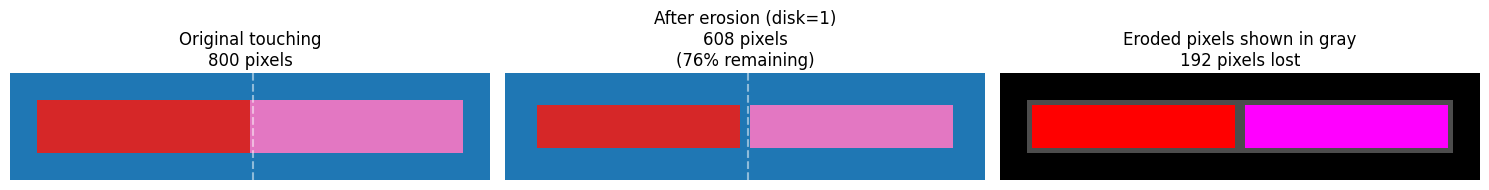


Erosion removes 192 pixels (24.0% of original)


In [27]:
# Visualize the erosion effect on the labels themselves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original touching
axes[0].imshow(labels_touching[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[0].set_title(f'Original touching\n{np.count_nonzero(labels_touching)} pixels')
axes[0].axvline(x=45, color='white', linestyle='--', alpha=0.5)  # boundary

# Eroded 
axes[1].imshow(labels_touching_eroded[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[1].set_title(f'After erosion (disk=1)\n{np.count_nonzero(labels_touching_eroded)} pixels\n({100*np.count_nonzero(labels_touching_eroded)/np.count_nonzero(labels_touching):.0f}% remaining)')
axes[1].axvline(x=45, color='white', linestyle='--', alpha=0.5)

# Overlay showing what was lost
lost = (labels_touching > 0) & (labels_touching_eroded == 0)
overlay = np.zeros((*labels_touching.shape, 3))
overlay[labels_touching_eroded == 1] = [1, 0, 0]  # red for label 1
overlay[labels_touching_eroded == 2] = [1, 0, 1]  # magenta for label 2
overlay[lost] = [0.3, 0.3, 0.3]  # gray for eroded pixels
axes[2].imshow(overlay[15:35, 5:95])
axes[2].set_title(f'Eroded pixels shown in gray\n{np.count_nonzero(lost)} pixels lost')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\nErosion removes {np.count_nonzero(lost)} pixels ({100*np.count_nonzero(lost)/np.count_nonzero(labels_touching):.1f}% of original)")

In [28]:
# The problem: our rectangles are only 10 pixels tall!
# Erosion with disk(1) removes ~3 pixels from each edge
# For thin objects, this is devastating

# Let's try with THICKER objects to see erosion work better
labels_thick = np.zeros((100, 100), dtype=np.uint16)
labels_thick[10:50, 10:45] = 1  # 40x35 rectangle
labels_thick[10:50, 45:90] = 2  # 40x45 rectangle (touching at x=45)

labels_thick_eroded = erode_labels(labels_thick, disk(1))

print("THICK objects:")
print(f"  Original: {np.count_nonzero(labels_thick)} pixels")
print(f"  Eroded: {np.count_nonzero(labels_thick_eroded)} pixels")
print(f"  Remaining: {100*np.count_nonzero(labels_thick_eroded)/np.count_nonzero(labels_thick):.1f}%")

print("\nTHIN objects (our test case):")
print(f"  Original: {np.count_nonzero(labels_touching)} pixels")  
print(f"  Eroded: {np.count_nonzero(labels_touching_eroded)} pixels")
print(f"  Remaining: {100*np.count_nonzero(labels_touching_eroded)/np.count_nonzero(labels_touching):.1f}%")

THICK objects:
  Original: 3200 pixels
  Eroded: 2888 pixels
  Remaining: 90.2%

THIN objects (our test case):
  Original: 800 pixels
  Eroded: 608 pixels
  Remaining: 76.0%


In [29]:
# Alternative: use a SMALLER erosion footprint
# disk(1) is actually a 3x3 cross, let's try just removing the touching edge

from skimage.morphology import binary_erosion, square

# Option 1: Use a 1-pixel line erosion (just separate at boundary)
def erode_labels_minimal(labels, iterations=1):
    """Erode each label by 1 pixel using binary erosion."""
    eroded = np.zeros_like(labels)
    for label_id in np.unique(labels):
        if label_id == 0:
            continue
        mask = labels == label_id
        for _ in range(iterations):
            mask = binary_erosion(mask)
        eroded[mask] = label_id
    return eroded

labels_minimal_erode = erode_labels_minimal(labels_touching, iterations=1)

print("Comparison of erosion methods on THIN objects:")
print(f"  Original: {np.count_nonzero(labels_touching)} pixels")
print(f"  disk(1) erosion: {np.count_nonzero(labels_touching_eroded)} pixels ({100*np.count_nonzero(labels_touching_eroded)/np.count_nonzero(labels_touching):.1f}%)")
print(f"  binary_erosion: {np.count_nonzero(labels_minimal_erode)} pixels ({100*np.count_nonzero(labels_minimal_erode)/np.count_nonzero(labels_touching):.1f}%)")

Comparison of erosion methods on THIN objects:
  Original: 800 pixels
  disk(1) erosion: 608 pixels (76.0%)
  binary_erosion: 608 pixels (76.0%)


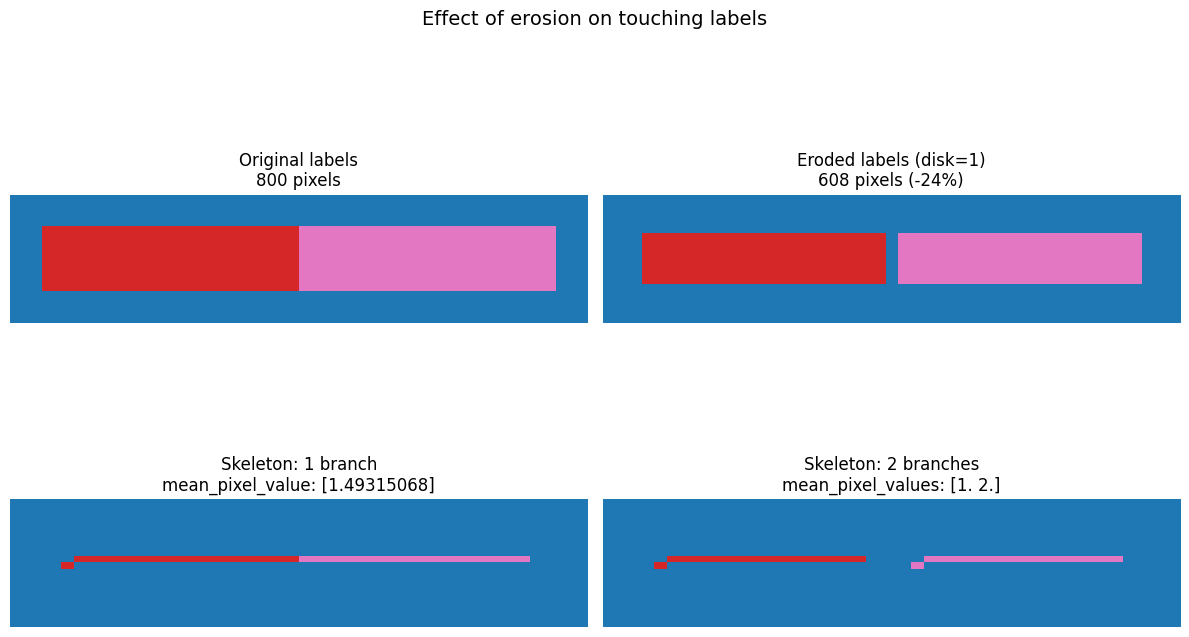


KEY INSIGHT:
Erosion removes pixels from ALL edges, not just the touching edge.
For thin objects (like our 10px tall rectangles), this loses ~24% of pixels.
For thick objects, erosion is more reasonable (~10% loss).

The tradeoff: lose some edge pixels to get clean label separation.


In [30]:
# Visual comparison: Original vs Eroded labels and their skeletons
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top left: Original labels
axes[0, 0].imshow(labels_touching[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[0, 0].set_title(f'Original labels\n{np.count_nonzero(labels_touching)} pixels')

# Top right: Eroded labels  
axes[0, 1].imshow(labels_touching_eroded[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[0, 1].set_title(f'Eroded labels (disk=1)\n{np.count_nonzero(labels_touching_eroded)} pixels (-24%)')

# Bottom left: Original skeleton
axes[1, 0].imshow(skeleton_touching[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[1, 0].set_title(f'Skeleton: {summary_touching.shape[0]} branch\nmean_pixel_value: {summary_touching["mean_pixel_value"].values}')

# Bottom right: Eroded skeleton
axes[1, 1].imshow(skeleton_touching_eroded[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[1, 1].set_title(f'Skeleton: {summary_touching_eroded.shape[0]} branches\nmean_pixel_values: {summary_touching_eroded["mean_pixel_value"].values}')

for ax in axes.flat:
    ax.axis('off')

plt.suptitle('Effect of erosion on touching labels', fontsize=14)
plt.tight_layout()
plt.show()

# Key insight
print("\nKEY INSIGHT:")
print("=" * 50)
print("Erosion removes pixels from ALL edges, not just the touching edge.")
print("For thin objects (like our 10px tall rectangles), this loses ~24% of pixels.")
print("For thick objects, erosion is more reasonable (~10% loss).")
print()
print("The tradeoff: lose some edge pixels to get clean label separation.")

## Better approach: Erode SKELETON at touching boundaries only

Instead of eroding labels (expensive, loses edge pixels everywhere), we can:
1. Skeletonize first (preserving labels)
2. Find where skeleton pixels from different labels touch
3. Remove just those touching pixels

In [31]:
def find_touching_skeleton_pixels(skeleton_labels):
    """Find skeleton pixels that are adjacent to pixels of a different label.
    
    Returns a mask of pixels that should be removed to separate touching skeletons.
    """
    from scipy import ndimage
    
    touching_mask = np.zeros_like(skeleton_labels, dtype=bool)
    
    # For each nonzero pixel, check if any neighbor has a different nonzero label
    # Use a 3x3 neighborhood (8-connectivity)
    for label_id in np.unique(skeleton_labels):
        if label_id == 0:
            continue
        
        # Dilate this label's skeleton
        this_label = skeleton_labels == label_id
        dilated = ndimage.binary_dilation(this_label)
        
        # Find where the dilated region overlaps with OTHER labels
        other_labels = (skeleton_labels > 0) & (skeleton_labels != label_id)
        overlap = dilated & other_labels
        
        # The touching pixels are where this label's skeleton touches other labels
        # We want to remove pixels from THIS label that are adjacent to other labels
        touching = this_label & ndimage.binary_dilation(other_labels)
        touching_mask |= touching
    
    return touching_mask

# Find touching pixels in our skeleton
touching_pixels = find_touching_skeleton_pixels(skeleton_touching)
print(f"Found {np.sum(touching_pixels)} touching skeleton pixels")

# Show where they are
rows, cols = np.where(touching_pixels)
for r, c in zip(rows, cols):
    print(f"  ({r}, {c}) = label {skeleton_touching[r, c]}")

Found 2 touching skeleton pixels
  (24, 49) = label 1
  (24, 50) = label 2


In [32]:
# Remove the touching pixels from the skeleton
skeleton_touching_separated = skeleton_touching.copy()
skeleton_touching_separated[touching_pixels] = 0

print("Original skeleton pixels:", np.count_nonzero(skeleton_touching))
print("After removing touching:", np.count_nonzero(skeleton_touching_separated))
print("Pixels removed:", np.sum(touching_pixels))
print()

# Check the boundary now
print("Boundary after separation:")
print("Row 24, cols 45-55:", skeleton_touching_separated[24, 45:56])

Original skeleton pixels: 73
After removing touching: 71
Pixels removed: 2

Boundary after separation:
Row 24, cols 45-55: [1 1 1 1 0 0 2 2 2 2 2]


In [33]:
# Analyze with skan
skel_separated = skan.Skeleton(skeleton_touching_separated)
summary_separated = skan.summarize(skel_separated, separator='_')

print("SKELETON-SEPARATED touching labels summary:")
print(summary_separated[['skeleton_id', 'branch_distance', 'branch_type', 'mean_pixel_value']])
print()
print(f"Number of skeleton_ids: {summary_separated['skeleton_id'].nunique()}")
print(f"mean_pixel_values: {summary_separated['mean_pixel_value'].unique()}")

SKELETON-SEPARATED touching labels summary:
   skeleton_id  branch_distance  branch_type  mean_pixel_value
0            0        35.414214            0               1.0
1            1        34.000000            0               2.0

Number of skeleton_ids: 2
mean_pixel_values: [1. 2.]


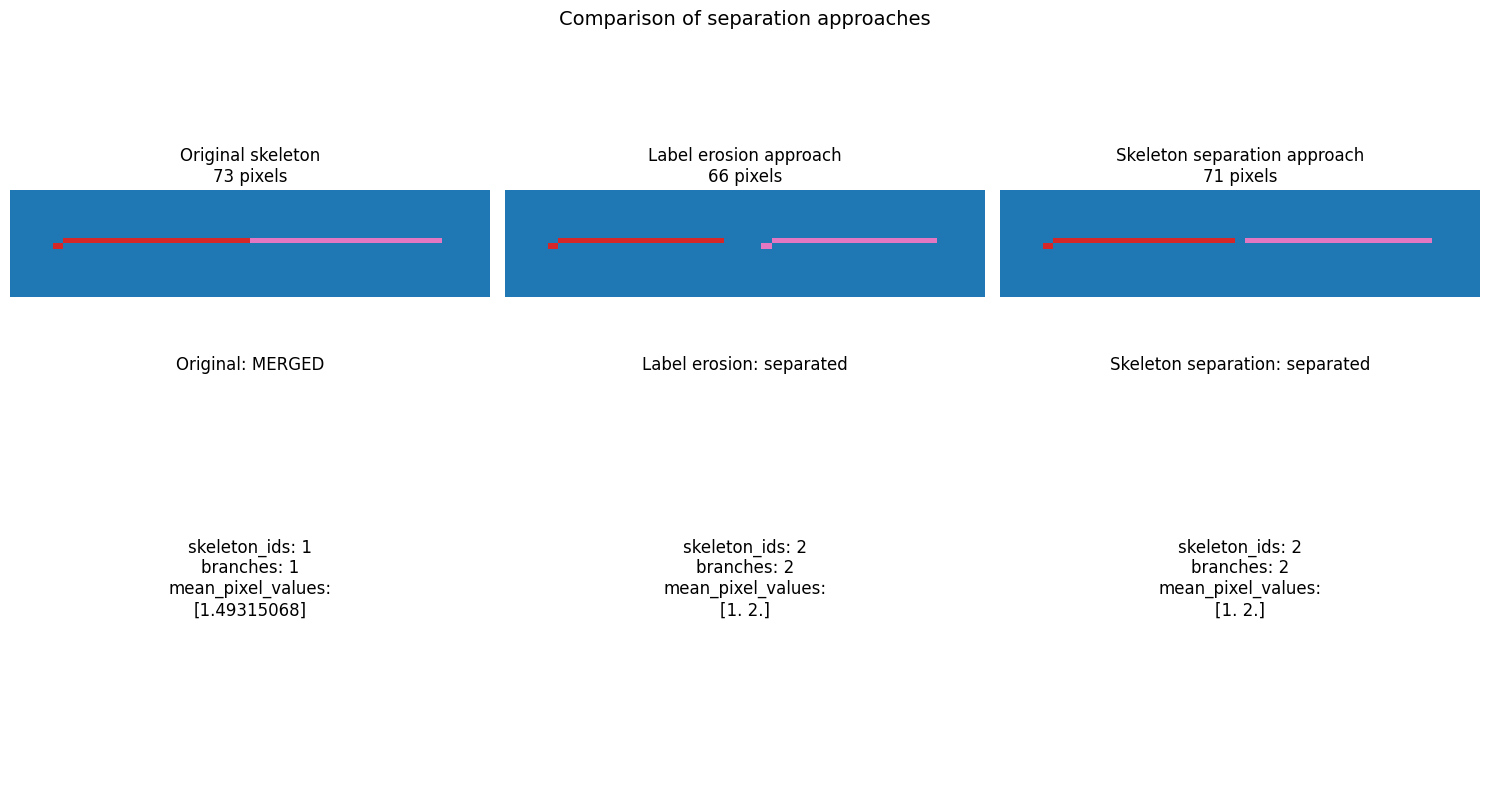


COMPARISON SUMMARY
Approach                  Pixels removed       Result                   
----------------------------------------------------------------------
Original                  0                    MERGED (1 branch)        
Label erosion             192=192 (24%)        Separated (2 branches)   
Skeleton separation       2=2 (2.7%)           Separated (2 branches)   


In [34]:
# Compare all three approaches
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Row 1: The three skeleton approaches
axes[0, 0].imshow(skeleton_touching[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[0, 0].set_title(f'Original skeleton\n{np.count_nonzero(skeleton_touching)} pixels')

axes[0, 1].imshow(skeleton_touching_eroded[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[0, 1].set_title(f'Label erosion approach\n{np.count_nonzero(skeleton_touching_eroded)} pixels')

axes[0, 2].imshow(skeleton_touching_separated[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[0, 2].set_title(f'Skeleton separation approach\n{np.count_nonzero(skeleton_touching_separated)} pixels')

# Row 2: skan results
def plot_skan_result(ax, summary, title):
    ax.text(0.5, 0.5, 
            f"skeleton_ids: {summary['skeleton_id'].nunique()}\n"
            f"branches: {len(summary)}\n"
            f"mean_pixel_values:\n{summary['mean_pixel_value'].unique()}",
            ha='center', va='center', fontsize=12,
            transform=ax.transAxes)
    ax.set_title(title)
    ax.axis('off')

plot_skan_result(axes[1, 0], summary_touching, "Original: MERGED")
plot_skan_result(axes[1, 1], summary_touching_eroded, "Label erosion: separated")
plot_skan_result(axes[1, 2], summary_separated, "Skeleton separation: separated")

for ax in axes[0]:
    ax.axis('off')

plt.suptitle('Comparison of separation approaches', fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*70)
print("COMPARISON SUMMARY")
print("="*70)
print(f"{'Approach':<25} {'Pixels removed':<20} {'Result':<25}")
print("-"*70)
print(f"{'Original':<25} {'0':<20} {'MERGED (1 branch)':<25}")
print(f"{'Label erosion':<25} {f'{800-608}=192 (24%)':<20} {'Separated (2 branches)':<25}")
print(f"{'Skeleton separation':<25} {f'{73-71}=2 (2.7%)':<20} {'Separated (2 branches)':<25}")
print("="*70)

In [35]:
# Clean function for the package
def separate_touching_skeletons(skeleton_labels):
    """Remove skeleton pixels where different labels touch.
    
    This is much more efficient than eroding labels before skeletonizing,
    as it only removes the minimal pixels needed to separate connected
    components from different original labels.
    
    Parameters
    ----------
    skeleton_labels : ndarray
        Labeled skeleton image where each pixel value is the original label ID.
        
    Returns
    -------
    separated : ndarray
        Skeleton with touching pixels removed. Pixels at label boundaries
        are set to 0.
        
    Notes
    -----
    For most biological images, skeletons rarely touch because objects are
    separated. This function handles the edge case where skeletons from
    adjacent labels happen to be neighbors.
    """
    from scipy import ndimage
    
    separated = skeleton_labels.copy()
    
    # Find pixels adjacent to a different nonzero label
    for label_id in np.unique(skeleton_labels):
        if label_id == 0:
            continue
        
        this_label = skeleton_labels == label_id
        other_labels = (skeleton_labels > 0) & (skeleton_labels != label_id)
        
        # Pixels of this label that touch other labels
        touching = this_label & ndimage.binary_dilation(other_labels)
        separated[touching] = 0
    
    return separated

# Test it
result = separate_touching_skeletons(skeleton_touching)
print(f"Function test: {np.count_nonzero(skeleton_touching)} -> {np.count_nonzero(result)} pixels")
print(f"Removed {np.count_nonzero(skeleton_touching) - np.count_nonzero(result)} touching pixels")b

Function test: 73 -> 71 pixels
Removed 2 touching pixels


In [36]:
viewer.add_labels(result, name="Separated Skeleton")

<Labels layer 'Separated Skeleton' at 0x23219d3c7d0>

## Test: Do diagonally touching skeletons get merged by skan?

In [42]:
# Create a GUARANTEED diagonally touching skeleton by directly placing pixels
# This removes the uncertainty of skeletonization

skeleton_diagonal = np.zeros((50, 50), dtype=np.uint16)

# Label 1: horizontal line ending at (20, 25)
skeleton_diagonal[20, 10:26] = 1

# Label 2: horizontal line starting at (21, 26) - DIAGONAL from (20, 25)
skeleton_diagonal[21, 26:40] = 2

print("Created skeleton with guaranteed diagonal adjacency:")
print("Label 1: row 20, cols 10-25 (ends at 20, 25)")
print("Label 2: row 21, cols 26-39 (starts at 21, 26)")
print()
print("Junction area:")
print(skeleton_diagonal[19:23, 24:28])
print()
print("Pixels at (20,25) and (21,26) are DIAGONALLY adjacent")

Created skeleton with guaranteed diagonal adjacency:
Label 1: row 20, cols 10-25 (ends at 20, 25)
Label 2: row 21, cols 26-39 (starts at 21, 26)

Junction area:
[[0 0 0 0]
 [1 1 0 0]
 [0 0 2 2]
 [0 0 0 0]]

Pixels at (20,25) and (21,26) are DIAGONALLY adjacent


In [41]:
# Skeletonize and check the result
skeleton_diagonal = skeletonize_labels(labels_diagonal)

print("Skeleton unique values:", np.unique(skeleton_diagonal))
print("Skeleton pixels per label:")
print(f"  Label 1: {np.sum(skeleton_diagonal == 1)} pixels")
print(f"  Label 2: {np.sum(skeleton_diagonal == 2)} pixels")

# Find where each skeleton ends/starts
label1_pixels = np.argwhere(skeleton_diagonal == 1)
label2_pixels = np.argwhere(skeleton_diagonal == 2)

print(f"\nLabel 1 skeleton range: rows {label1_pixels[:,0].min()}-{label1_pixels[:,0].max()}, cols {label1_pixels[:,1].min()}-{label1_pixels[:,1].max()}")
print(f"Label 2 skeleton range: rows {label2_pixels[:,0].min()}-{label2_pixels[:,0].max()}, cols {label2_pixels[:,1].min()}-{label2_pixels[:,1].max()}")

# Check if they are diagonally adjacent
print("\nLooking for diagonal adjacency...")

Skeleton unique values: [0 1 2]
Skeleton pixels per label:
  Label 1: 17 pixels
  Label 2: 16 pixels

Label 1 skeleton range: rows 21-22, cols 7-23
Label 2 skeleton range: rows 24-25, cols 28-43

Looking for diagonal adjacency...


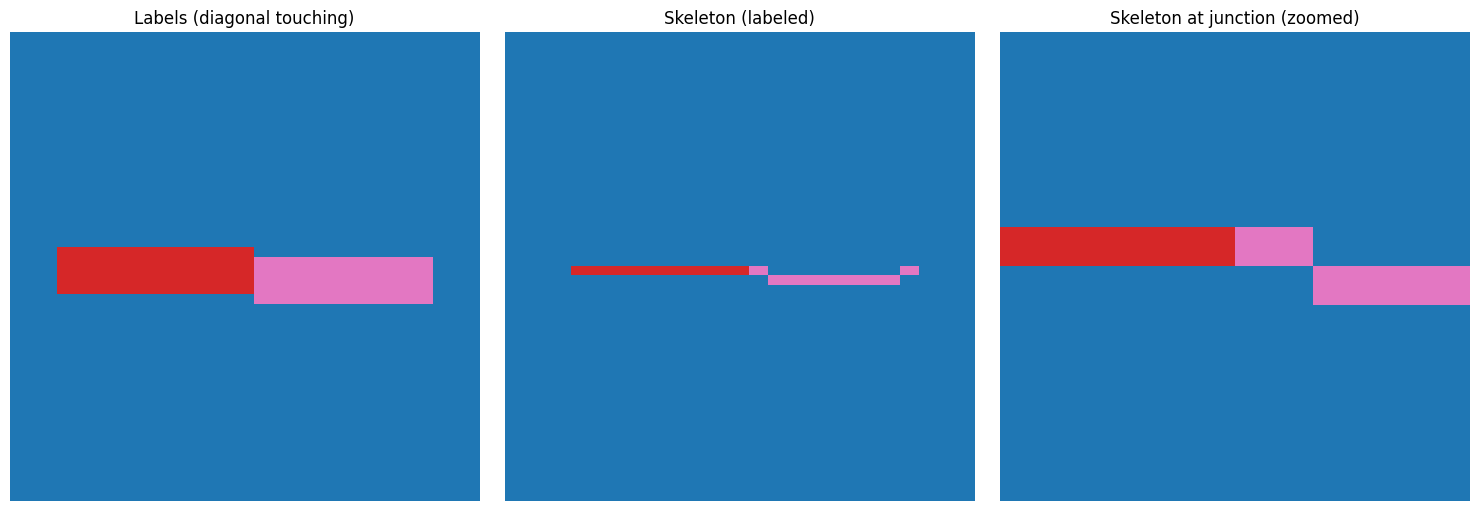


Skeleton values around potential junction:
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [1 1 1 2 2 0]
 [0 0 0 0 0 2]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


In [39]:
# Visualize the diagonal case
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(labels_diagonal, cmap='tab10', vmin=0, vmax=3)
axes[0].set_title('Labels (diagonal touching)')

axes[1].imshow(skeleton_diagonal, cmap='tab10', vmin=0, vmax=3)
axes[1].set_title('Skeleton (labeled)')

# Zoom in on the junction
axes[2].imshow(skeleton_diagonal[20:32, 20:32], cmap='tab10', vmin=0, vmax=3)
axes[2].set_title('Skeleton at junction (zoomed)')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Print the actual values around the junction
print("\nSkeleton values around potential junction:")
print(skeleton_diagonal[23:29, 23:29])

In [43]:
# Run skan on the diagonal skeleton - does it see 1 or 2 skeleton_ids?
skel_diagonal = skan.Skeleton(skeleton_diagonal)
summary_diagonal = skan.summarize(skel_diagonal, separator='_')

print("Diagonal skeleton skan summary:")
print(summary_diagonal[['skeleton_id', 'branch_distance', 'branch_type', 'mean_pixel_value']])
print()
print(f"Number of skeleton_ids: {summary_diagonal['skeleton_id'].nunique()}")
print(f"mean_pixel_values: {summary_diagonal['mean_pixel_value'].unique()}")

if summary_diagonal['skeleton_id'].nunique() == 1:
    print("\n⚠️  CONFIRMED: Diagonally touching skeletons ARE MERGED by skan!")
else:
    print("\n✓ Diagonally touching skeletons are separate")

Diagonal skeleton skan summary:
   skeleton_id  branch_distance  branch_type  mean_pixel_value
0            0        29.414214            0          1.466667

Number of skeleton_ids: 1
mean_pixel_values: [1.46666667]

⚠️  CONFIRMED: Diagonally touching skeletons ARE MERGED by skan!


In [47]:
# Clear cache and reimport with updated function
import sys
for mod in list(sys.modules.keys()):
    if 'ndev_morphology' in mod:
        del sys.modules[mod]

from ndev_morphology import separate_touching_skeleton_labels

# Test the UPDATED separate_touching_skeletons function on diagonal case
skeleton_diagonal_separated = separate_touching_skeleton_labels(skeleton_diagonal)

print(f"Original diagonal skeleton: {np.count_nonzero(skeleton_diagonal)} pixels")
print(f"After separation: {np.count_nonzero(skeleton_diagonal_separated)} pixels")
print(f"Pixels removed: {np.count_nonzero(skeleton_diagonal) - np.count_nonzero(skeleton_diagonal_separated)}")

print("\nJunction area after separation:")
print(skeleton_diagonal_separated[19:23, 24:28])

# Check if skan now sees them as separate
skel_diagonal_sep = skan.Skeleton(skeleton_diagonal_separated)
summary_diagonal_sep = skan.summarize(skel_diagonal_sep, separator='_')

print("\nAfter separation:")
print(f"Number of skeleton_ids: {summary_diagonal_sep['skeleton_id'].nunique()}")
print(f"mean_pixel_values: {summary_diagonal_sep['mean_pixel_value'].unique()}")

if summary_diagonal_sep['skeleton_id'].nunique() == 1:
    print("\n⚠️  Still merged!")
else:
    print("\n✓ SUCCESS! Diagonally touching skeletons are now separated!")

Original diagonal skeleton: 30 pixels
After separation: 28 pixels
Pixels removed: 2

Junction area after separation:
[[0 0 0 0]
 [1 0 0 0]
 [0 0 0 2]
 [0 0 0 0]]

After separation:
Number of skeleton_ids: 2
mean_pixel_values: [1. 2.]

✓ SUCCESS! Diagonally touching skeletons are now separated!


In [48]:
# Test both orthogonal AND diagonal cases with the updated function
print("="*60)
print("COMPREHENSIVE TEST: Orthogonal and Diagonal touching")
print("="*60)

# Test 1: Orthogonal (horizontal touching)
skeleton_ortho = np.zeros((20, 40), dtype=np.uint16)
skeleton_ortho[10, 5:20] = 1
skeleton_ortho[10, 20:35] = 2  # Touching at (10, 19) and (10, 20)

result_ortho = separate_touching_skeleton_labels(skeleton_ortho)
skel_ortho = skan.Skeleton(result_ortho)
summary_ortho = skan.summarize(skel_ortho, separator='_')

print("\n1. ORTHOGONAL touching (side by side):")
print(f"   Before: {np.count_nonzero(skeleton_ortho)} pixels")
print(f"   After:  {np.count_nonzero(result_ortho)} pixels")
print(f"   skeleton_ids: {summary_ortho['skeleton_id'].nunique()}")
print(f"   ✓ PASS" if summary_ortho['skeleton_id'].nunique() == 2 else "   ✗ FAIL")

# Test 2: Diagonal touching
skeleton_diag = np.zeros((20, 40), dtype=np.uint16)
skeleton_diag[9, 5:20] = 1   # Ends at (9, 19)
skeleton_diag[10, 20:35] = 2  # Starts at (10, 20) - diagonal from (9, 19)

result_diag = separate_touching_skeleton_labels(skeleton_diag)
skel_diag = skan.Skeleton(result_diag)
summary_diag = skan.summarize(skel_diag, separator='_')

print("\n2. DIAGONAL touching:")
print(f"   Before: {np.count_nonzero(skeleton_diag)} pixels")
print(f"   After:  {np.count_nonzero(result_diag)} pixels")
print(f"   skeleton_ids: {summary_diag['skeleton_id'].nunique()}")
print(f"   ✓ PASS" if summary_diag['skeleton_id'].nunique() == 2 else "   ✗ FAIL")

# Test 3: Non-touching (should be unchanged)
skeleton_sep = np.zeros((20, 40), dtype=np.uint16)
skeleton_sep[5, 5:20] = 1
skeleton_sep[15, 5:20] = 2  # Far apart

result_sep = separate_touching_skeleton_labels(skeleton_sep)
print("\n3. NON-TOUCHING (should be unchanged):")
print(f"   Before: {np.count_nonzero(skeleton_sep)} pixels")
print(f"   After:  {np.count_nonzero(result_sep)} pixels")
print(f"   ✓ PASS" if np.array_equal(skeleton_sep, result_sep) else "   ✗ FAIL")

COMPREHENSIVE TEST: Orthogonal and Diagonal touching

1. ORTHOGONAL touching (side by side):
   Before: 30 pixels
   After:  28 pixels
   skeleton_ids: 2
   ✓ PASS

2. DIAGONAL touching:
   Before: 30 pixels
   After:  28 pixels
   skeleton_ids: 2
   ✓ PASS

3. NON-TOUCHING (should be unchanged):
   Before: 30 pixels
   After:  30 pixels
   ✓ PASS


In [24]:
# Now skeletonize the eroded labels
skeleton_touching_eroded = skeletonize_labels(labels_touching_eroded)

print("Eroded skeleton unique values:", np.unique(skeleton_touching_eroded))
print("Eroded skeleton nonzero pixels:", np.count_nonzero(skeleton_touching_eroded))

# Check the boundary region - should now have a gap!
print("\nBoundary region after erosion:")
print("Row 24, cols 45-55:", skeleton_touching_eroded[24, 45:56])

Eroded skeleton unique values: [0 1 2]
Eroded skeleton nonzero pixels: 66

Boundary region after erosion:
Row 24, cols 45-55: [1 0 0 0 0 0 0 0 0 0 2]


In [25]:
# Analyze with skan
skel_touching_eroded = skan.Skeleton(skeleton_touching_eroded)
summary_touching_eroded = skan.summarize(skel_touching_eroded, separator='_')

print("ERODED touching labels summary:")
print(summary_touching_eroded[['skeleton_id', 'branch_distance', 'branch_type', 'mean_pixel_value']])
print()
print(f"Number of skeleton_ids: {summary_touching_eroded['skeleton_id'].nunique()}")
print(f"mean_pixel_values: {summary_touching_eroded['mean_pixel_value'].unique()}")

ERODED touching labels summary:
   skeleton_id  branch_distance  branch_type  mean_pixel_value
0            0        32.414214            0               1.0
1            1        32.414214            0               2.0

Number of skeleton_ids: 2
mean_pixel_values: [1. 2.]


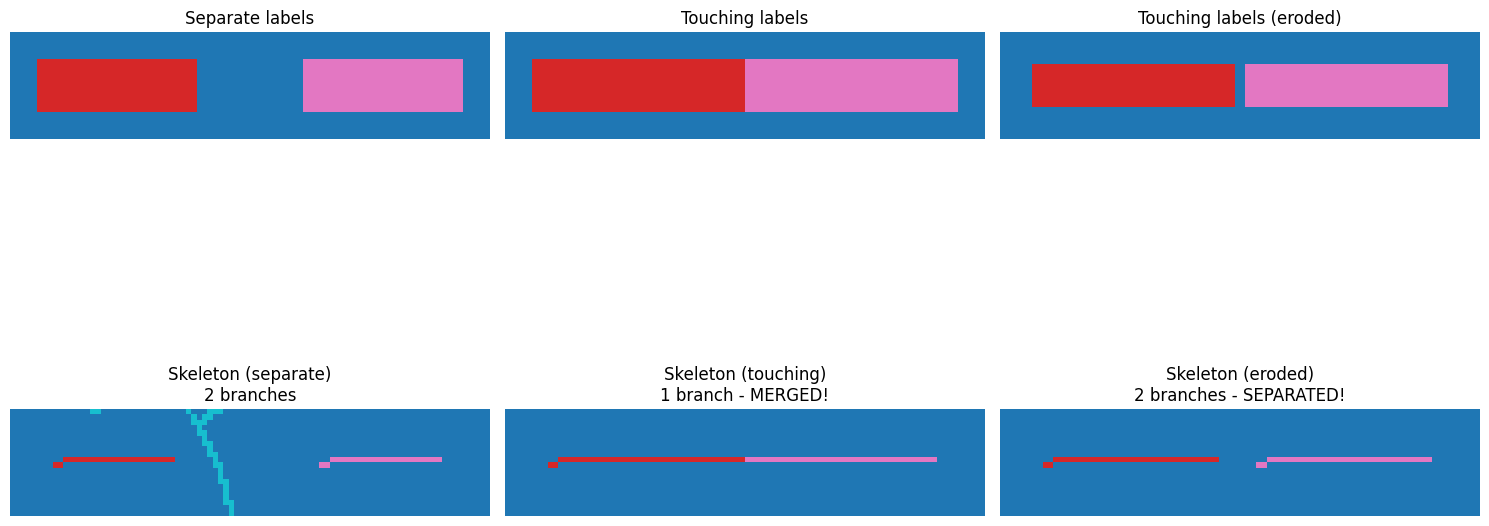

In [26]:
# Compare all three cases visually
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Labels
axes[0, 0].imshow(labels_separate[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[0, 0].set_title('Separate labels')
axes[0, 1].imshow(labels_touching[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[0, 1].set_title('Touching labels')
axes[0, 2].imshow(labels_touching_eroded[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[0, 2].set_title('Touching labels (eroded)')

# Row 2: Skeletons
axes[1, 0].imshow(skeleton_separate[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[1, 0].set_title(f'Skeleton (separate)\n{summary_separate.shape[0]} branches')
axes[1, 1].imshow(skeleton_touching[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[1, 1].set_title(f'Skeleton (touching)\n{summary_touching.shape[0]} branch - MERGED!')
axes[1, 2].imshow(skeleton_touching_eroded[15:35, 5:95], cmap='tab10', vmin=0, vmax=3)
axes[1, 2].set_title(f'Skeleton (eroded)\n{summary_touching_eroded.shape[0]} branches - SEPARATED!')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Key question: Does skan see them as one skeleton or two?

In [21]:
print("SEPARATE labels:")
print(f"  Number of skeleton_ids: {summary_separate['skeleton_id'].nunique()}")
print(f"  skeleton_ids: {summary_separate['skeleton_id'].unique()}")
print(f"  mean_pixel_values: {summary_separate['mean_pixel_value'].unique()}")

print("\nTOUCHING labels:")
print(f"  Number of skeleton_ids: {summary_touching['skeleton_id'].nunique()}")
print(f"  skeleton_ids: {summary_touching['skeleton_id'].unique()}")
print(f"  mean_pixel_values: {summary_touching['mean_pixel_value'].unique()}")

SEPARATE labels:
  Number of skeleton_ids: 2
  skeleton_ids: [0 1]
  mean_pixel_values: [1. 2.]

TOUCHING labels:
  Number of skeleton_ids: 1
  skeleton_ids: [0]
  mean_pixel_values: [1.49315068]


## Visualize in napari

In [22]:
import napari

viewer = napari.Viewer()

# Add separate case
viewer.add_labels(labels_separate, name='labels_separate')
viewer.add_labels(skeleton_separate, name='skeleton_separate')

# Add touching case  
viewer.add_labels(labels_touching, name='labels_touching', visible=False)
viewer.add_labels(skeleton_touching, name='skeleton_touching', visible=False)

<Labels layer 'skeleton_touching' at 0x23283c30cd0>

In [ ]:
# Now use skan's napari widget to convert to shapes
# Go to Plugins > skan > Labels to Skeleton Shapes
# Then try coloring by 'mean_pixel_value' vs 'skeleton_id'